-----
# AM10 - Computing for Science and Engineering - Module 3

## Homework 11

**Fall 2020**

Handed out: Thursday, Nov. 19

Due: 11.59 am; Thursday, Dec. 3rd

-----

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Problem 1: Monte Carlo integration of a 2D Gaussian

The unnormalized 2D Gaussian function is given by 
\begin{equation}
g_{2d}(x, y) = A\exp{\left ( -\left [ \frac{(x-x_0)^2}{2\sigma_x^2} + \frac{(y-y_0)^2}{2\sigma_y^2} \right ] \right )},
\end{equation}
where, $A$ is the amplitude of the Gaussian, ($x_0$, $y_0$) is the center, and $\sigma_x$ and $\sigma_y$ are the standard deviations along $x$ and $y$, respectively, (representing the spread of the Gaussian). You might remember the 2D Gaussian from Lecture 8.

**Part A:** Write a Python function (call it `gauss2d`) that implements the 2D Gaussian above. The inputs to your Python function should be $A$, $x_0$, $y_0$, $\sigma_x$, $\sigma_y$, as well as $x$ and $y$. 

In [12]:
def gauss2d(A,x0,y0,sigx,sigy,x,y):
    return A*np.exp(-(x-x0)**2/(2*sigx**2)-(y-y0)**2/(2*sigy**2))

**Part B:** Evaluate the integral of the 2D Gaussian using the Monte Carlo method with 10000 points. The theoretical integral of this form of a 2D Gaussian over all $x$ and $y$, *i.e.* $\int_{-\infty}^{+\infty}g_{2d}(x, y)$, is $2A\pi\sigma_x\sigma_y$. Confirm that your Monte Carlo function produces a value close to the theoretical value by printing out the result of the Monte Carlo integration as well as the theoretical value. Also, print out the percentage error between the numerical and theoretical result. The percentage error is given by 
$$\left \vert \frac{I_{theo}-I_{num}}{I_{theo}} \right \vert \times 100$$

Use the following parameters for the Gaussian: $x_0=0$, $y_0=0$, $A=2$, $\sigma_x=1$, and $\sigma_y=3$. Use the range of $\pm 3\sigma_x$ and $\pm 3\sigma_y$ for $x$ and $y$, respectively.

In [5]:
# define parameters 
nump = 10000 
A = 2
x0 = 0
y0 = 0
sigx = 1 
sigy = 3
ax = -3 * sigx
bx = 3 * sigx
ay = -3 * sigy
by = 3 * sigy

def mcint_2d(func, nump, ax, bx, ay, by): # from class! 
    '''
        Input:
            func: Python function representing the mathematical function to be integrated
            nump: number of random samples to draw for Monte Carlo
            ax: minimum of range along x
            bx: maximum of range along x
            ay: minimum of range along y
            by: maximum of range along y            
        Output:
            intfin: value of the integral
    '''
    intsum = 0 # initialize 
    for i in range(nump): 
        x = ax + np.random.rand() * (bx - ax)
        y = ay + np.random.rand() * (by - ay)
        intsum = intsum + func(x,y)
    intfin = (bx - ax) * (by - ay) * intsum / nump
    
    return intfin 

def Gaussian(x,y): # we only want x and y as inputs in the for loop 
    return A*np.exp(-(x-x0)**2/(2*sigx**2)-(y-y0)**2/(2*sigy**2))

MC = mcint_2d(Gaussian, nump, ax, bx, ay, by) # my Monte Carlo method approximation 
theoretical = 2 * A * np.pi * sigx * sigy # calculation of the analytical result
percent = np.abs((theoretical- MC)/theoretical*100) # finding the absolute percent error
print("The result of the Monte Carlo method is", MC)
print("The theoretical result is", theoretical)
print("The absolute percentage error is",percent)

The result of the Monte Carlo method is 37.475965015712674
The theoretical result is 37.69911184307752
The absolute percentage error is 0.5919153435064768


### Problem 2: Let's play Roulette

Going with the *Monte Carlo* theme let's play a game of roulette. Roulette is a common casino game where a wheel with 37 slots (numbered 0 to 36) is spun around. Then a small ball is thrown on the spinning wheel and allowed to come to rest in one of the slots. Players can place bets, for example, on whether the ball will come to rest in an even slot or an odd slot. Note that the slot numbered 0 is considered neither odd nor even and for even/odd bets getting slot 0 means that you lose irrespective of the bet.

Let's assume that the ball has equal probability of coming to rest in any of the 37 slots. You have \\$100 to wager. Each wager is \\$10 in amount and you can choose place a bet on whether the ball ends up in an odd or an even slot. Because you are smart and you know that the game is tilted in favor of the casino, you let a coin toss decide whether to bet on odd or even. A winning bet gets you \\$10 while a losing bet means you lose \\$10.

**Part A:** Write code to implement this roulette game and find (print) out how many wagers you can place before you lose all your money, i.e. you are left with less than \\$10. Plot the amount of money you have as a function of the wager number.

*Feel free to run your code multiple times to look at the different scenarios you get with different sets of random numbers. Share screenshots of your plot on the AM10 Slack channel and the luckiest person (with the most number of wagers before losing all money) gets bragging rights!*

*Hints:* 
1. You can use the function `np.random.randint` to generate random integers in a given range. For example, to simulate a coin toss, you can generate random integers in the range 0 to 2 (excludes 2) and choose, say, 0 to be heads and 1 to be tails.

2. You can write a `while` loop that runs as long as the money left is greater than the amout of a single bet (\\$10).

3. In each iteration of the loop a winning bet increases the money you have by \\$10 while a losing bet decreases the money by \\$10.

4. Use `if` statements to check whether your random bet wins/loses according to the random slot picked. Note that slot 0 is considered neither even nor odd, meaning you always lose if the ball comes to rest in slot 0.

5. Create an empty list before the loop. You can append to this list the value of money you have at each iteration for plotting.


If I start with $100, I can make 1381 bets


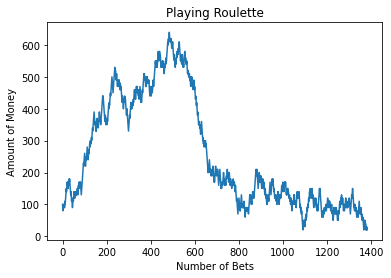

In [13]:
money = 100 # starting money 
wallet = [] # list to hold record of how much money I have 
wager = 0 # initialize to keep track of how many bets I make 

while money > 10:
    wallet.append(money) # append wallet with how much money I have at the moment 
    bet = np.random.randint(0,2) # from the coin flip 
    spin = np.random.randint(0,37) # Roulette spin
    
    if spin == 0: # for the 0 situation (lose)
        money = money - 10
    
    elif spin % 2 == bet: # for when it matches my bet (win)
        money = money + 10
        
    else:
        money = money - 10 # for when it does not match my bet (lose)
    
    wager = wager + 1 # keep track of wagers made
    
plt.plot(wallet) # plot the track of my wallet 
plt.xlabel('Number of Bets')
plt.ylabel('Amount of Money')
plt.title("Playing Roulette")
print("If I start with $100, I can make", wager, "bets") 

**Part B:** Now, modify your roulette code such that you place exactly 100 wagers. Run 100 of these roulette games, where in each game you place 100 wagers. All the other conditions are the same, i.e. you start with \\$100 and the bet amount is \\$10.
1. Calculate the average amount of money you lose or win (averaged over the 100 games) after 100 wagers.
2. Plot the money as a function of the wager number for each simulation (i.e. all 100 curves of money as a function of wager number)

*Hints:*
1. You can replace the `while` loop with a `for` loop for going over the 100 wagers.
2. An additional `for` loop will be needed for running the game 100 times.
3. Initialize an array to hold the amount of money you have at each iteration for plotting. Update this array in the inner `for` loop and update the plot in the outer `for` loop.

PART 1
The net change in money is -33.5 dollars per game for 100 games and 100 wagers
PART 2


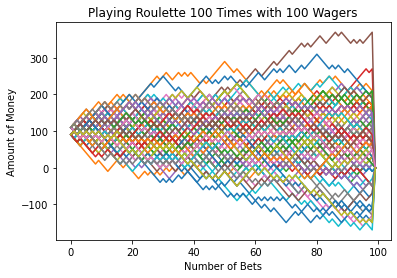

In [15]:
finalmoney = np.zeros(100)
for g in range(99): # for loop for running the game 100 times (outer for loop)
    money = 100
    wallet = np.zeros(100) 
    for w in range(99): # for loop for the 100 wagers
        bet = np.random.randint(0,2) # from the coin flip 
        spin = np.random.randint(0,37) # Roulette spin
    
        if spin == 0: # for the 0 situation (lose)
            money = money - 10
    
        elif spin % 2 == bet: # for when it matches my bet (win)
            money = money + 10
        
        else:
            money = money - 10 # for when it does not match my bet (lose)
        wallet[w] = money # keep track of how much money I have in my wallet at each wager in an array called wallet
    finalmoney[g] = wallet[w] # keep track of the amount of money I have at the end of each game in an array called finalmoney
    plt.plot(wallet)
print("PART 1")
averagemoney = np.mean(finalmoney) # averaging the total money lost or won (finalmoney) after 100 wagers 
netmoney = averagemoney - 100 # calculate net money (final - initial)
print("The net change in money is",np.round(netmoney,4),"dollars per game for 100 games and 100 wagers")
print("PART 2")
plt.xlabel('Number of Bets')
plt.ylabel('Amount of Money')
plt.title('Playing Roulette 100 Times with 100 Wagers')
plt.show()


***Optional*** **Part C:** 
Modify your code to roughly estimate how many wagers on average can you place before you start losing money to the casino? Take the average over 100 games. Keep the starting money and the bet amount the same, i.e., \\$100 and \\$10, respectively. Plot the average money won/lost as a function of number of wagers. On the same figure add a dashed line for marking the 0 value on the y-axis and see where the money curve crosses the zero-line.

*Hints:*
1. Create a linearly spaced array for the number of wagers from 1 to say 500 in steps of 5.
2. You will need yet another `for` loop to go over all these values for the number of wagers.

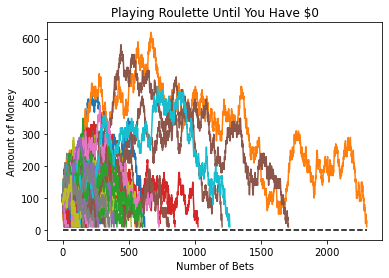

I estimate that if I play 100 games of Roulette, I can place 267.26 bets on average before I start losing money to the casino, i.e. the amount of money I have in my wallet reaches 0


In [30]:
bets = np.zeros(100) # initalize array of size 100 to keep track of how many bets I make in each game
for g in range(99): # for loop to play 100 games 
    money = 100 # starting money 
    wallet = [] # list to hold record of how much money I have 
    wager = 0 # initialize to keep track of how many bets I make 
    while money > 0:
        wallet.append(money) # append wallet with how much money I have at the moment 
        bet = np.random.randint(0,2) # from the coin flip 
        spin = np.random.randint(0,37) # Roulette spin
    
        if spin == 0: # for the 0 situation (lose)
            money = money - 10
    
        elif spin % 2 == bet: # for when it matches my bet (win)
            money = money + 10
        
        else:
            money = money - 10 # for when it does not match my bet (lose)
    
        wager = wager + 1 # keep track of wagers made
    plt.plot(wallet) # plot the track of my wallet 
    bets[g] = len(wallet) # keep track of how many bets I made in each game by tracking the entries in the wallet
averagebets=np.mean(bets) # average the amount of bets over the 100 games
plt.xlabel('Number of Bets')
plt.ylabel('Amount of Money')
plt.title("Playing Roulette Until You Have $0")
plt.hlines(0, 0, np.max(bets), colors='k', linestyles='dashed') # dashed line at y = 0
plt.show()
print("I estimate that if I play 100 games of Roulette, I can place",averagebets,"bets on average before I start losing money to the casino, i.e. the amount of money I have in my wallet reaches 0")